# **Machine Learning Project**






## Students:
1. **Mustafa Mallesho** 222110520
2. **Mohammad Aqib** 221111317
3. **Naif Hazzaa Alrous** 222110926

## Dataset:
https://www.kaggle.com/datasets/turkibintalib/saudiarabia-used-cars-dataset

## Selection Approval:
This dataset is suitable for multiple machine learning tasks, including:
- **Regression:** Predicting car prices based on features like brand, model, year, and mileage.
- **Clustering:** Grouping similar cars based on specifications for market segmentation.

## Project Problem-Objective Statement:
- **Problem:** The pricing of used cars in Saudi Arabia is influenced by various factors such as brand, year, mileage, and transmission type. Buyers and sellers often struggle to estimate fair prices, leading to inefficiencies in the market.
- **Objective:** Develop a machine learning model to accurately predict the price of used cars in Saudi Arabia based on their specifications. The model will help users make informed buying and selling decisions by providing fair price estimates.

# **Data Preparation**

In [ ]:
#Load dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("turkibintalib/saudi-arabia-used-cars-dataset") #this dataset is ideal for building models to predict car prices based on various features.

100%|██████████| 1.34M/1.34M [00:00<00:00, 1.82MB/s]

Extracting files...


In [ ]:
import pandas as pd

#load dataset into a dataframe
df = pd.read_csv("/content/UsedCarsSA_Clean_EN.csv")

# Dropping duplicates if any
df = df.drop_duplicates()
#Looking for missing values
df.isnull().sum() # There are no missing values

,0
Make,0
Type,0
Year,0
Origin,0
Color,0
Options,0
Engine_Size,0
Fuel_Type,0
Gear_Type,0
Mileage,0


In [ ]:
df

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,0,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000,False
8032,Toyota,Land Cruiser,2013,Gulf Arabic,White,Full,4.6,Gas,Automatic,260,Najran,0,True
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000,False


In [ ]:
# Dropping rows with price less than 4000 so that it does not affect the models predictions (as they are not reasonable)
df = df.loc[df['Price'] >= 7000]
# Limiting the max value of Milage to 600_000 so that we can adjust its standard deviation
df = df[df['Mileage'] <=600_000]





In [ ]:
# Size of the dataset after cleaning
df.reset_index(drop=True, inplace=True)
len(df)

5363

# **EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error

In [ ]:
# EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5363 entries, 0 to 5362
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         5363 non-null   object 
 1   Type         5363 non-null   object 
 2   Year         5363 non-null   int64  
 3   Origin       5363 non-null   object 
 4   Color        5363 non-null   object 
 5   Options      5363 non-null   object 
 6   Engine_Size  5363 non-null   float64
 7   Fuel_Type    5363 non-null   object 
 8   Gear_Type    5363 non-null   object 
 9   Mileage      5363 non-null   int64  
 10  Region       5363 non-null   object 
 11  Price        5363 non-null   int64  
 12  Negotiable   5363 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(8)
memory usage: 508.1+ KB


In [ ]:
df.describe()

,Year,Engine_Size,Mileage,Price
count,5363.000000,5363.000000,5363.000000,5.363000e+03
mean,2014.870408,3.184244,125529.413761,8.017689e+04
std,5.028878,1.468174,106532.976141,7.510282e+04
min,1963.000000,1.000000,100.000000,7.000000e+03
25%,2013.000000,2.000000,47407.000000,3.700000e+04
50%,2016.000000,2.700000,101000.000000,5.900000e+04
75%,2018.000000,4.000000,180000.000000,9.500000e+04
max,2021.000000,9.000000,600000.000000,1.150000e+06


In [ ]:
df.isnull().sum()

,0
Make,0
Type,0
Year,0
Origin,0
Color,0
Options,0
Engine_Size,0
Fuel_Type,0
Gear_Type,0
Mileage,0


In [ ]:
#As the nogotiable column has no effect on data, we can drop it..
df.drop(columns='Negotiable',inplace=True)

In [ ]:
df.describe()

,Year,Engine_Size,Mileage,Price
count,5363.000000,5363.000000,5363.000000,5.363000e+03
mean,2014.870408,3.184244,125529.413761,8.017689e+04
std,5.028878,1.468174,106532.976141,7.510282e+04
min,1963.000000,1.000000,100.000000,7.000000e+03
25%,2013.000000,2.000000,47407.000000,3.700000e+04
50%,2016.000000,2.700000,101000.000000,5.900000e+04
75%,2018.000000,4.000000,180000.000000,9.500000e+04
max,2021.000000,9.000000,600000.000000,1.150000e+06


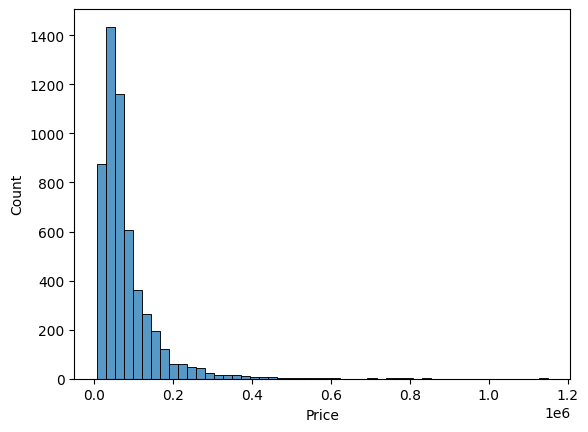

In [ ]:
#Check car price distribution

sns.histplot(df.Price,bins=50)
plt.show()

<ipython-input-14-681fc16ac3d3>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=make_vs_price.values, y=make_vs_price.index, palette=colors)
<ipython-input-14-681fc16ac3d3>:8: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(x=make_vs_price.values, y=make_vs_price.index, palette=colors)


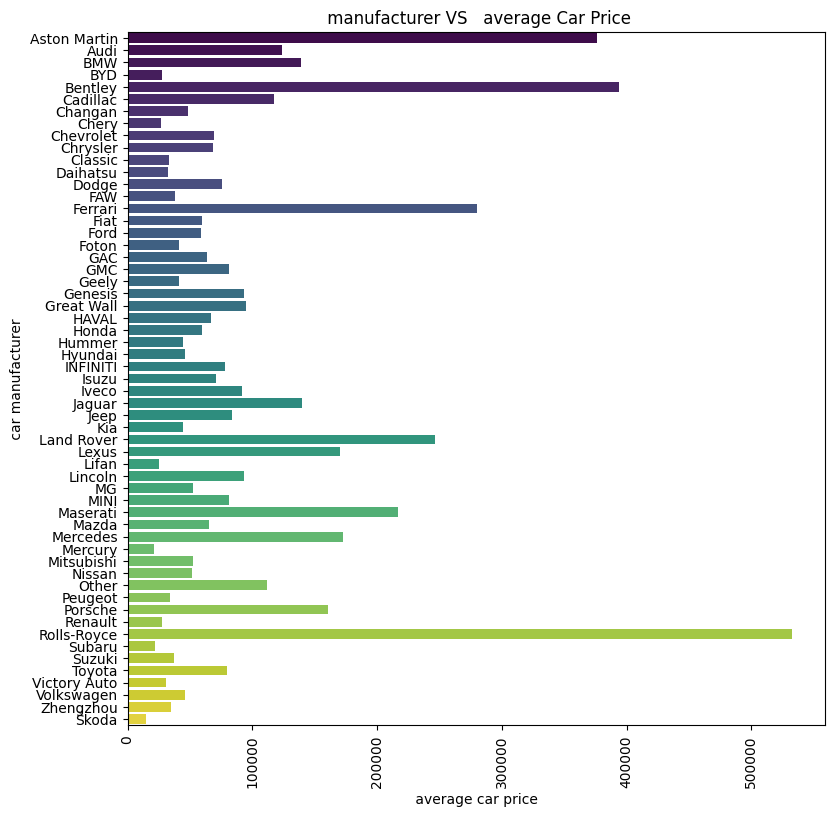

In [ ]:

make_vs_price = df.groupby('Make')['Price'].mean()
plt.figure(figsize=(9, 9))

# Generate a list of colors, one for each bar
num_bars = len(make_vs_price)
colors = plt.cm.viridis(np.linspace(0, 1, num_bars))  # Use viridis colormap

sns.barplot(x=make_vs_price.values, y=make_vs_price.index, palette=colors)
plt.xticks(rotation=90)
plt.ylabel(' car manufacturer ')
plt.xlabel(' average car price ')
plt.title(' manufacturer VS   average Car Price')
plt.show()

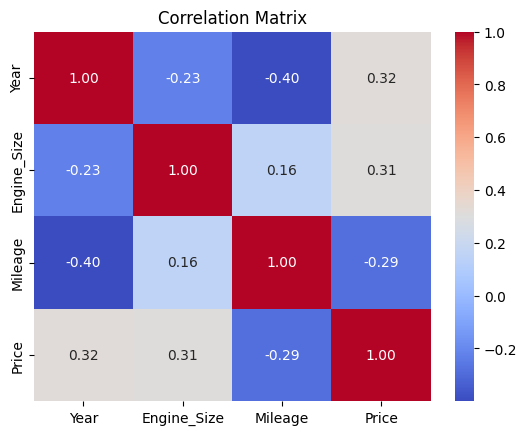

In [ ]:
# Checking correlation matrix of numerical columns
numeric_columns = df.select_dtypes(include=['float64', 'int64'])

# Generate the correlation matrix
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

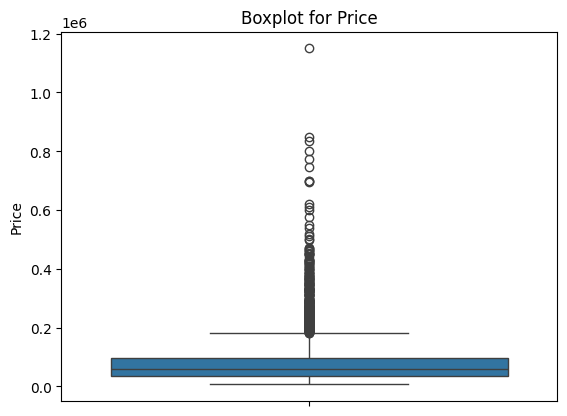

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the box plot for 'Price'
sns.boxplot(data=df, y='Price')
plt.title("Boxplot for Price")
plt.show()

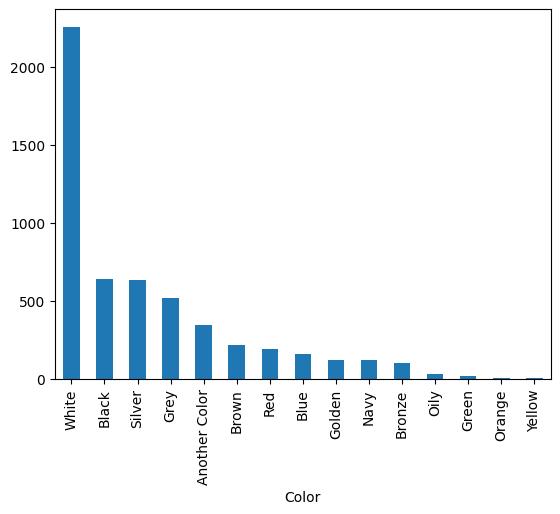

In [ ]:
#Unique colors of car
car_colour=df.Color.value_counts()
car_colour.plot(kind='bar')
plt.show()

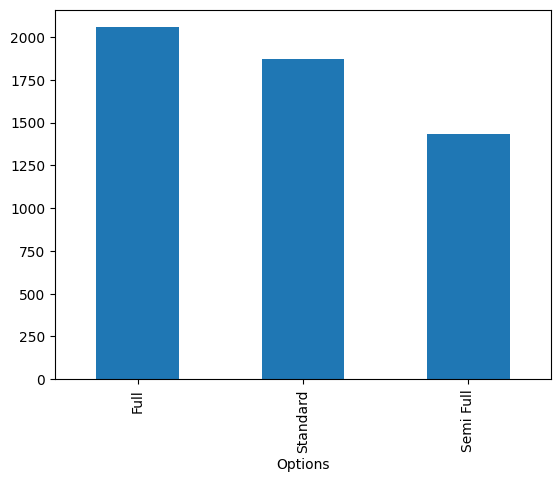

In [ ]:
# check the option values...
car_options=df.Options.value_counts()
car_options.plot(kind='bar')
plt.show()


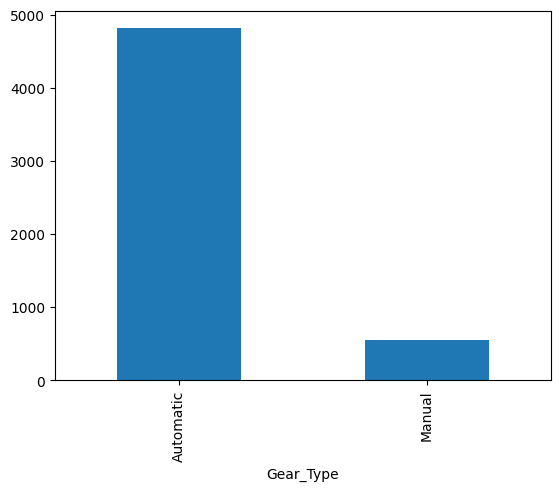

In [ ]:
#Automatic and manual
car_gear_type=df.Gear_Type.value_counts()
car_gear_type.plot(kind='bar')
plt.show()

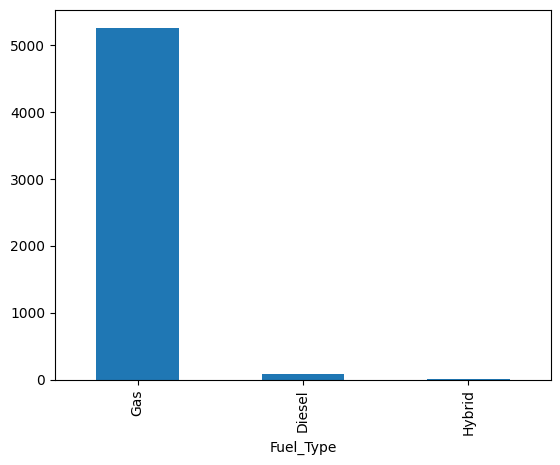

In [ ]:
#Fuel Type
car_fuel_type=df.Fuel_Type.value_counts()
car_fuel_type.plot(kind='bar')
plt.show()

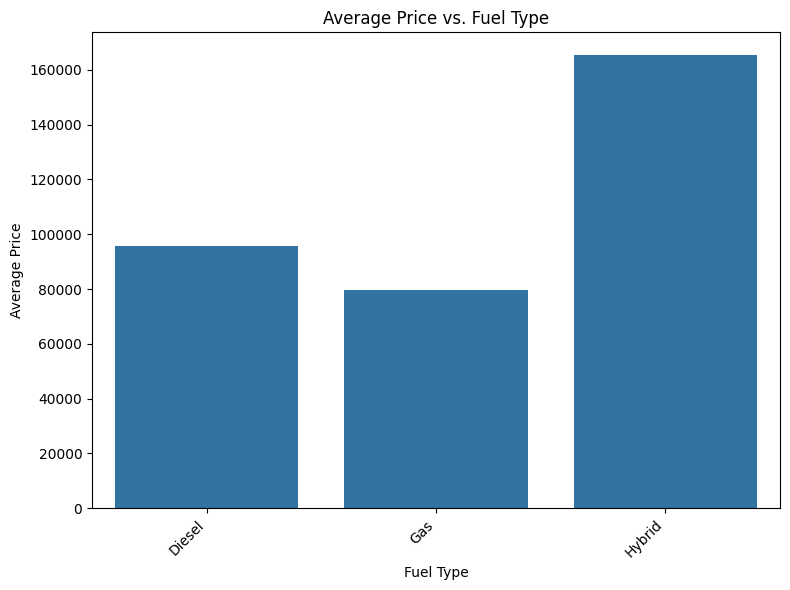

In [ ]:
# avgCar price  vs Fuel_Type
# Calculate average price for each fuel type
fuel_type_avg_price = df.groupby('Fuel_Type')['Price'].mean()

# Create the bar plot
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.barplot(x=fuel_type_avg_price.index, y=fuel_type_avg_price.values)
plt.title('Average Price vs. Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

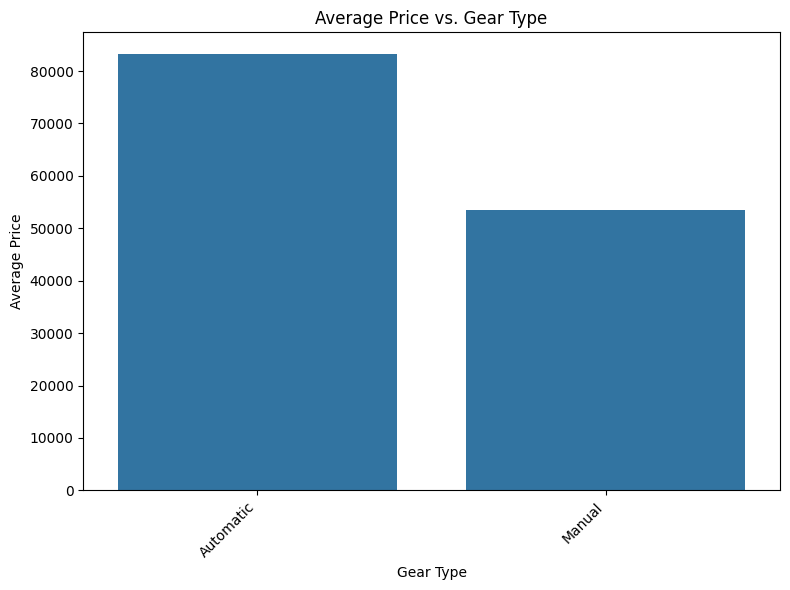

In [ ]:
# avgCar price  vs Gear_Type

# Calculate average price for each gear type
gear_type_avg_price = df.groupby('Gear_Type')['Price'].mean()

# Create the bar plot
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.barplot(x=gear_type_avg_price.index, y=gear_type_avg_price.values)
plt.title('Average Price vs. Gear Type')
plt.xlabel('Gear Type')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

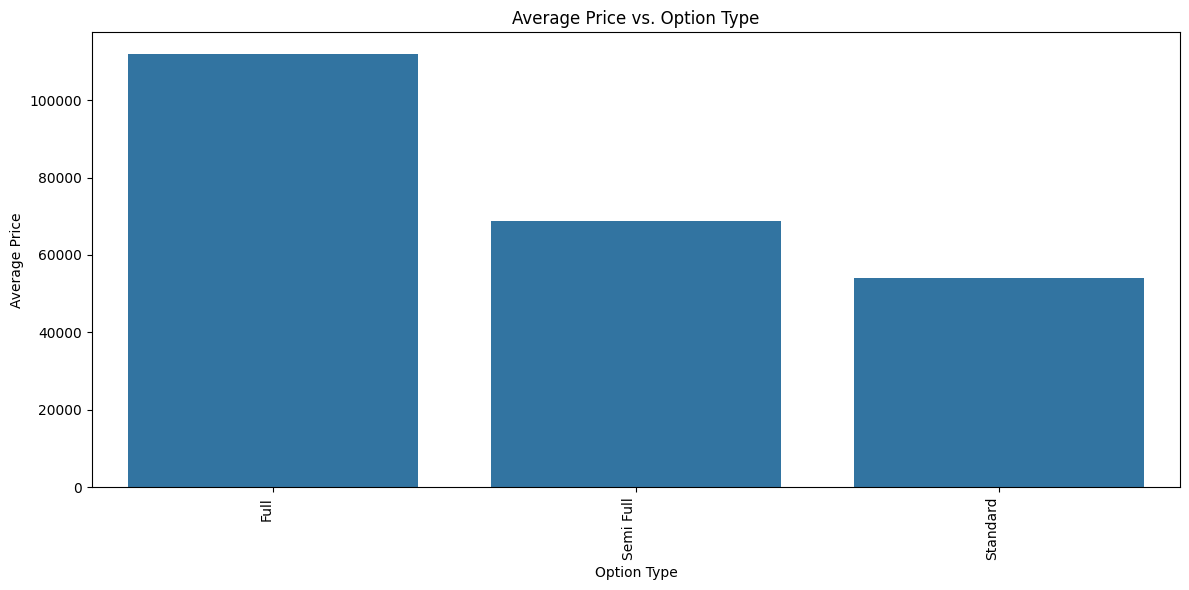

In [ ]:
# avgCar price  vs CarOptions

# Calculate average price for each option type
option_type_avg_price = df.groupby('Options')['Price'].mean()

# Create the bar plot
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
sns.barplot(x=option_type_avg_price.index, y=option_type_avg_price.values)
plt.title('Average Price vs. Option Type')
plt.xlabel('Option Type')
plt.ylabel('Average Price')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

## 📊 Exploratory Data Analysis (EDA) Summary

## 💰 Price Distribution
- The histogram of car prices shows a **right-skewed distribution**:
  - Most cars are priced on the **lower end**, with a few **very expensive** outliers.
  - This skewness may need to be **addressed during model training**, potentially using **log transformation** to stabilize variance and improve model performance.

---
## 💰 Price Distribution
- The histogram of car prices shows a **right-skewed distribution**:
  - Most cars are priced on the **lower end**, with a few **very expensive** outliers.
  - This skewness may need to be **addressed during model training**, potentially using **log transformation** to stabilize variance and improve model performance.

---

## 🔗 Correlation Matrix Insights

1. **Year vs Price**  
   - 🟢 Positive correlation (**0.32**): Newer cars tend to be more expensive.

2. **Engine Size vs Price**  
   - 🟢 Positive correlation (**0.31**): Vehicles with larger engines generally cost more.

3. **Mileage vs Price**  
   - 🔴 Negative correlation (**-0.29**): Cars with higher mileage are usually priced lower.

4. **Year vs Mileage**  
   - 🔴 Negative correlation (**-0.40**): Newer vehicles typically have lower mileage.

5. **Year vs Engine Size**  
   - 🔵 Slight negative correlation (**-0.23**): Newer cars may be trending toward smaller engines (e.g., for efficiency).

6. **Engine Size vs Mileage**  
   - 🟡 Slight positive correlation (**0.16**): Cars with larger engines might be used more or for longer distances.

---

## 📦 Boxplot Insight: `Price`

- The boxplot of `Price` shows a **right-skewed distribution** with a **large number of outliers** on the higher end.
- The **interquartile range (IQR)** is relatively narrow compared to the extreme values, which suggests:
  - Most vehicles are priced within a certain range.
  - A **small subset of vehicles** are priced much higher, potentially **luxury or premium models**.
- The presence of **extreme outliers** (e.g., prices exceeding **600,000**) could:
  - **Distort statistical metrics** like mean.
  - **Negatively impact** model training, especially for models sensitive to scale (e.g., linear regression).


### ✅ Summary
- In general, the `Price` feature exhibits significant skew and outliers.

---


## 🧩 Categorical Feature Analysis and Insights
- The bar plots for **Color**, **Options**, **Gear Type**, and **Fuel Type** show the distribution of these categories.
- Vehicles with full options have the highest average price, significantly surpassing both semi-full and standard options. This indicates that fully loaded cars, often including premium features like advanced safety, luxury interiors, and cutting-edge technology, command a higher market price.   Semi-full option cars have a mid-range average price and cars with standard options have the lowest average price.
- Vehicles with automatic transmissions have a substantially higher average price compared to manual cars. This reflects the convenience and advanced technology often included in automatic cars, such as adaptive gear systems and smoother driving experience.                Manual cars tend to be cheaper, potentially due to simpler mechanical designs, lower manufacturing costs, and less demand in markets where automatics are preferred.
- Hybrid Cars are the Most Expensive: The average price for hybrid cars is significantly higher than both diesel and gas cars, indicating a premium for hybrid technology. This could be due to the combination of electric and gasoline powertrains, advanced battery systems, and potentially more luxury features.                                                                                                                                                     Diesel vehicles have a mid-range average price, sitting between gas and hybrid cars. This might reflect their efficiency and durability, often preferred for long-distance driving and commercial use.      Among the three fuel types, gas-powered cars have the lowest average price, likely due to the widespread availability of gas engines and lower manufacturing costs compared to hybrid systems.
---

## 🚀 Next Steps
- Use these insights to guide **feature engineering**, and **model selection**.
- Apply appropriate transformations and encoding strategies to prepare the dataset for modeling.


# **Feature Engineering**

## **Description of Selected Features and Rationale:**
**Note : These features were selected depending on: EDA, variance, and domain related.**

- Engine_Size

Description: size of the car’s engine, mostly measured in liters.

Rationale: Larger engines associated with better performance of the car, which logically contribute to a higher value of the car's market and price.

- Year

Description: The year the car was manufactured.

Rationale: The newer the car the better the mechanics and technology inside it, the more expensive it is.

- Make

Description: Car's brand (e.g., Toyota, BMW, Mercedes).

Rationale: Different brands have different demands and customer reliabilities. For example, luxury brands like Mercedes worth more in terms of prices than economic brands.

- Type

Description: Car's category (typically determined by size).

Rationale: Different types have different demands. SUVs and Trucks tend to be more expensive than smaller sedans due to their size, power, and versatility.

- Options

Description: Some more features in the car such as sunproof and leasther seats

Rationale: The better and more the good options the more the price.

- Mileage

Description: The total distance the car has traveled (in km or mi).

Rationale: The higher the mileage, the higher the probability of damages, and thus this reduces the market value of the car.

- Gear_Type

Description: The total distance the car has traveled (in km or mi).

Rationale: Transmission type affects both driving experience and maintenance costs. Automatic transmissions typically command higher prices than manual ones, with specialized systems like dual-clutch transmissions often valued even higher in the market.

**Note : We can add an interaction term for car_age : 2025 - year.**

In [ ]:
# Features_selected = df[['Type','Make','Year', 'Options','Engine_Size','Gear_Type', 'Mileage', 'Price']]
from sklearn.preprocessing import StandardScaler

# Define the columns to scale
numeric_cols = ['Year', 'Engine_Size', 'Mileage']

# Initialize scaler
scaler = StandardScaler()

# Fit and transform the numeric columns
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

# Reassign to Features_selected with scaled values
Features_selected = df_scaled[['Type', 'Make', 'Year', 'Options', 'Engine_Size', 'Gear_Type', 'Mileage', 'Price']]


In [ ]:
cat_features = ['Type', 'Options', 'Gear_Type', 'Make']

# One-hot encode categorical features - because most of the categorial features do not have natural ordering
dummies = pd.get_dummies(Features_selected[cat_features], drop_first=True)

Features_selected = pd.concat([Features_selected.drop(columns=cat_features), dummies], axis=1)

#**Model Building**

In [ ]:
# Importing libraries and splitting test_train set
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
X = Features_selected.drop(columns=['Price'])
y = Features_selected['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train



,Year,Engine_Size,Mileage,Type_3,Type_300,Type_3008,Type_301,Type_307,Type_360,Type_4Runner,...,Make_Porsche,Make_Renault,Make_Rolls-Royce,Make_Subaru,Make_Suzuki,Make_Toyota,Make_Victory Auto,Make_Volkswagen,Make_Zhengzhou,Make_Škoda
1471,0.224642,-0.125504,-0.317137,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4305,0.025772,0.555678,-0.455577,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
644,0.224642,0.419442,0.051356,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3295,0.224642,-0.466094,0.558288,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3961,0.025772,-0.466094,-0.408638,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3092,0.821252,0.555678,-0.633942,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3772,-1.565188,2.122396,0.492575,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5191,0.224642,-1.147276,0.417474,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5226,0.025772,0.215087,0.248496,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**We will implement 4 Regression Models:**
- Linear Regression
- Neural Network
- Decision Tree
- XGBoost Regressor

In [ ]:
# Linear Regression
lr_model = LinearRegression() # No specific hyper parameters
lr_model.fit(X_train, y_train)

y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# use lasso or ridge - reduce rsme

lr_train_r2 = r2_score(y_train, y_train_pred_lr)
lr_test_r2 = r2_score(y_test, y_test_pred_lr)



print(f"🔹 **Linear Regression Performance**")
print(f"Train R² Score: {lr_train_r2:.3f} | Test R² Score: {lr_test_r2:.3f}")



🔹 **Linear Regression Performance**
Train R² Score: 0.763 | Test R² Score: 0.718


In [ ]:
# Neural Network Regressor
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
]) # Optimized NN arch, more complex increases the risk of overfitting

# Compile
nn_model.compile(optimizer=Adam(learning_rate=0.005), loss='mse')

# Train
nn_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

# Predictions
y_train_pred_nn = nn_model.predict(X_train).flatten()
y_test_pred_nn = nn_model.predict(X_test).flatten()

# Evaluation
print("🔹Neural Network Regressor:")
print(f"Training R²: {r2_score(y_train, y_train_pred_nn):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred_nn):.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
🔹Neural Network Regressor:
Training R²: 0.9342
Test R²: 0.8825


In [ ]:
# Decision Tree Regressor
# Initialize the model
dt_model = DecisionTreeRegressor(max_depth=7, random_state=42) # This max depth 7 is good , higher will increase the risk of overfitting

# Fit the model
dt_model.fit(X_train, y_train)

# Predict
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Evaluate
print("🔹 Decision Tree Regressor:")
print(f"Training R²: {r2_score(y_train, y_train_pred_dt):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred_dt):.4f}")


🔹 Decision Tree Regressor:
Training R²: 0.7880
Test R²: 0.7614


In [ ]:
# XGBoost Regressor
xgb_reg  = xgb.XGBRegressor( max_depth=4,learning_rate=0.0755, n_estimators=300,  subsample=0.7,  colsample_bytree=0.7, random_state=42)
# max_depth is pretty inflencing in our case, value 4 is optimal(higher / lower results in over/under fitting risks)
xgb_reg.fit(X_train, y_train)


y_train_pred_xgb = xgb_reg.predict(X_train)
y_test_pred_xgb = xgb_reg.predict(X_test)

print("🔹 XGBoost:")
print(f"Training R²: {r2_score(y_train, y_train_pred_xgb):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred_xgb):.4f}")


🔹 XGBoost:
Training R²: 0.9394
Test R²: 0.8937


# **Models Evaluation and Comparison**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Store predictions for all models
models = {
    "Linear Regression": (y_train_pred_lr, y_test_pred_lr),
    "Neural Network": (y_train_pred_nn, y_test_pred_nn),
    "Decision Tree": (y_train_pred_dt, y_test_pred_dt),
    "XGBoost": (y_train_pred_xgb, y_test_pred_xgb)
}

results = []

for name, (train_preds, test_preds) in models.items():
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

    results.append({
        "Model": name,
        "Train R²": round(train_r2, 4),
        "Test R²": round(test_r2, 4),
        "Train RMSE": round(train_rmse, 2),
        "Test RMSE": round(test_rmse, 2)
    })

# Convert to DataFrame for comparison
results_df = pd.DataFrame(results)
print("🔍 Model Performance Comparison:")
print(results_df.to_string(index=False))


🔍 Model Performance Comparison:
            Model  Train R²  Test R²  Train RMSE  Test RMSE
Linear Regression    0.7631   0.7176    36161.76   41561.54
   Neural Network    0.9342   0.8825    19051.93   26803.39
    Decision Tree    0.7880   0.7614    34211.84   38199.26
          XGBoost    0.9394   0.8937    18285.89   25495.45


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error, explained_variance_score
import pandas as pd
import numpy as np

# Store predictions for all models
models = {
    "Linear Regression": (y_train_pred_lr, y_test_pred_lr),
    "Neural Network": (y_train_pred_nn, y_test_pred_nn),
    "Decision Tree": (y_train_pred_dt, y_test_pred_dt),
    "XGBoost": (y_train_pred_xgb, y_test_pred_xgb)
}

results = []

for name, (train_preds, test_preds) in models.items():
    # R² score (coefficient of determination)
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    # Root Mean Squared Error (RMSE)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

    # Mean Absolute Error (MAE)
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)

    # Mean Absolute Percentage Error (MAPE)
    # Using try/except to handle potential zero values in y_true
    try:
        train_mape = mean_absolute_percentage_error(y_train, train_preds)
        test_mape = mean_absolute_percentage_error(y_test, test_preds)
    except:
        # Calculate MAPE manually with handling for zeros
        train_mape = np.mean(np.abs((y_train - train_preds) / np.maximum(np.abs(y_train), 1e-10))) * 100
        test_mape = np.mean(np.abs((y_test - test_preds) / np.maximum(np.abs(y_test), 1e-10))) * 100

    # Explained Variance Score
    train_evs = explained_variance_score(y_train, train_preds)
    test_evs = explained_variance_score(y_test, test_preds)

    # Max Error
    train_max_error = np.max(np.abs(y_train - train_preds))
    test_max_error = np.max(np.abs(y_test - test_preds))

    results.append({
        "Model": name,
        "Train R²": round(train_r2, 4),
        "Test R²": round(test_r2, 4),
        "Train RMSE": round(train_rmse, 2),
        "Test RMSE": round(test_rmse, 2),
        "Train MAE": round(train_mae, 2),
        "Test MAE": round(test_mae, 2),
        "Train MAPE (%)": round(train_mape * 100, 2),
        "Test MAPE (%)": round(test_mape * 100, 2),
        "Train EVS": round(train_evs, 4),
        "Test EVS": round(test_evs, 4),
        "Train Max Error": round(train_max_error, 2),
        "Test Max Error": round(test_max_error, 2)
    })

# Convert to DataFrame for comparison
results_df = pd.DataFrame(results)
print("🔍 Model Performance Comparison:")
print(results_df.to_string(index=False))

# Display a subset of metrics for easier viewing (optional)
important_metrics = ["Model", "Test R²", "Test RMSE", "Test MAE", "Test MAPE (%)", "Test EVS"]
print("\n🏆 Key Performance Metrics:")
print(results_df[important_metrics].to_string(index=False))

🔍 Model Performance Comparison:
            Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  Train MAPE (%)  Test MAPE (%)  Train EVS  Test EVS  Train Max Error  Test Max Error
Linear Regression    0.7631   0.7176    36161.76   41561.54   18761.50  21517.60           38.33          40.17     0.7631    0.7178        488259.17       595586.46
   Neural Network    0.9342   0.8825    19051.93   26803.39    9030.09  12606.40           12.89          18.03     0.9343    0.8831        352017.08       373335.44
    Decision Tree    0.7880   0.7614    34211.84   38199.26   22336.70  24308.09           38.64          39.72     0.7880    0.7614        325274.91       350000.00
          XGBoost    0.9394   0.8937    18285.89   25495.45   11933.81  14045.79           20.28          22.21     0.9394    0.8938        174059.91       398217.12

🏆 Key Performance Metrics:
            Model  Test R²  Test RMSE  Test MAE  Test MAPE (%)  Test EVS
Linear Regression   0.7176   41561.54

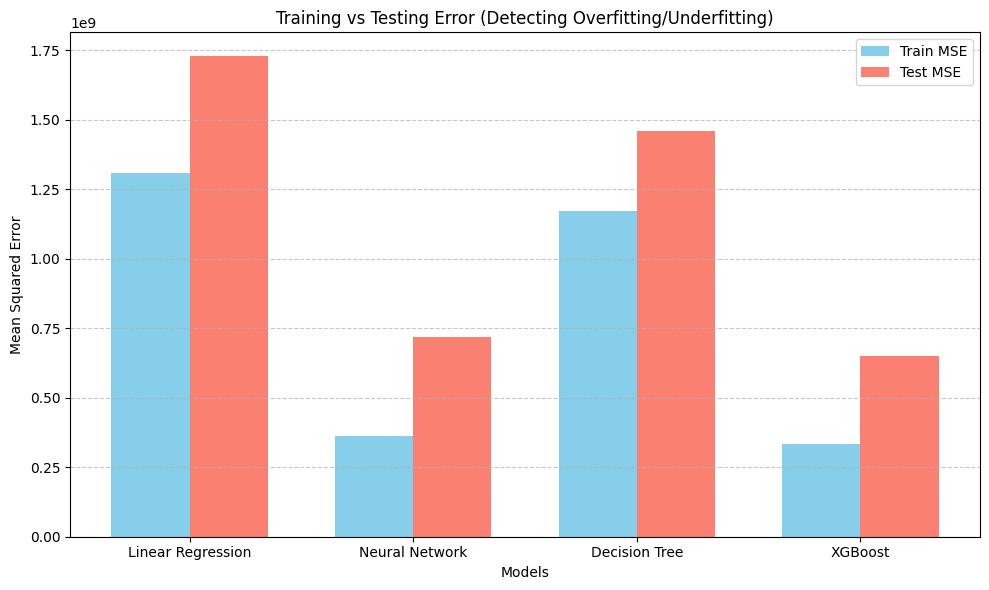

In [ ]:
# Visualization
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Actual target values
# y_train and y_test must already be defined

# Dictionary of model predictions
models = {
    "Linear Regression": (y_train_pred_lr, y_test_pred_lr),
    "Neural Network": (y_train_pred_nn, y_test_pred_nn),
    "Decision Tree": (y_train_pred_dt, y_test_pred_dt),
    "XGBoost": (y_train_pred_xgb, y_test_pred_xgb)
}

train_errors = []
test_errors = []
model_names = []

# Calculate mean squared errors
for name, (y_train_pred, y_test_pred) in models.items():
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    model_names.append(name)

# Plotting
x = range(len(model_names))
bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x, train_errors, width=bar_width, label='Train MSE', color='skyblue')
plt.bar([i + bar_width for i in x], test_errors, width=bar_width, label='Test MSE', color='salmon')
plt.xlabel('Models')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Testing Error (Detecting Overfitting/Underfitting)')
plt.xticks([i + bar_width / 2 for i in x], model_names)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


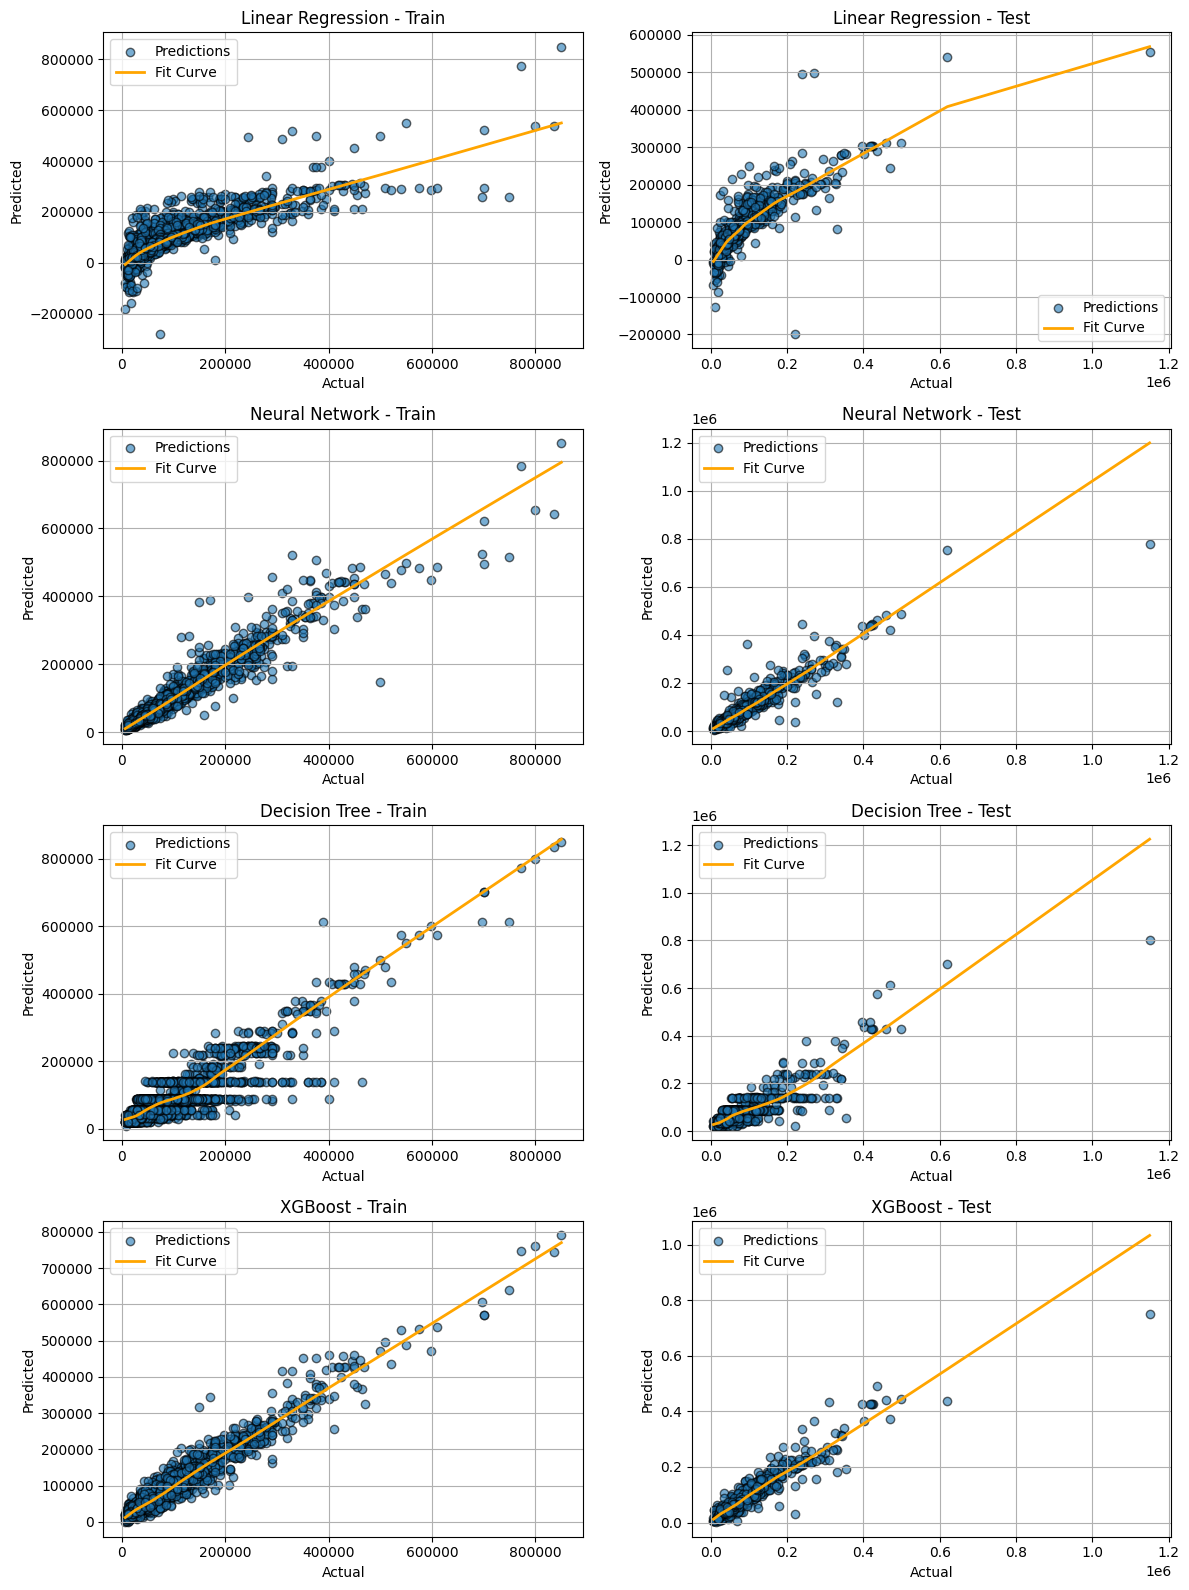

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm  # For lowess smoothing

def plot_scatter(y_true, y_pred, title, ax):
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', label='Predictions')
    #ax.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', label='Ideal Fit (y = x)')

    # LOWESS curve (locally weighted scatterplot smoothing)
    lowess = sm.nonparametric.lowess
    smoothed = lowess(y_pred, y_true, frac=0.3)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='orange', linewidth=2, label='Fit Curve')

    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)


# Plotting
fig, axes = plt.subplots(len(models), 2, figsize=(12, 4 * len(models)))

for idx, (name, (y_train_pred, y_test_pred)) in enumerate(models.items()):
    plot_scatter(y_train, y_train_pred, f'{name} - Train', axes[idx, 0])
    plot_scatter(y_test, y_test_pred, f'{name} - Test', axes[idx, 1])

plt.tight_layout()
plt.show()


#**Model Comparison and Selection Report**


## Visual Analysis of Model Performance

The scatter plots reveal how well each model's predictions match actual values. The yellow fit curves represent the ideal prediction line (where predicted = actual), while blue dots show actual predictions. Points closer to the fit curve indicate more accurate predictions.

Additionally, the MSE (Mean Squared Error) bar chart provides a quantitative comparison of model errors, highlighting the difference between training and testing performance.

## Detailed Model Evaluation

### Linear Regression
- **R² Performance**: Achieves the lowest R² values (0.7631/0.7176) among all models
- **Error Metrics**: Highest RMSE (41561.54) and MAE (21517.60) in testing
- **Percentage Error**: Poor MAPE performance (40.17% in testing)
- **Observations**: The model shows the largest maximum error in both training (468259.17) and testing (595560.46). The scatter plots confirm this with significant deviations from the fit line, including negative predictions for low actual values.

### Neural Network
- **R² Performance**: Strong R² values (0.9342/0.8825) indicating good fit
- **Error Metrics**: Best RMSE performance in training (19051.93) and excellent testing RMSE (26803.39)
- **Percentage Error**: Outstanding MAPE scores (12.89%/18.03%) - the lowest among all models
- **Observations**: The scatter plots show tight clustering around the fit line with consistent performance across the value range. Maximum errors (352017.08/373335.44) are moderate compared to other models.

### Decision Tree
- **R² Performance**: Moderate R² values (0.7880/0.7614), better than Linear Regression but significantly worse than Neural Network and XGBoost
- **Error Metrics**: High RMSE (34211.84/38199.26) and highest MAE in testing (24308.09)
- **Percentage Error**: Poor MAPE performance (39.72% in testing), similar to Linear Regression
- **Observations**: Scatter plots show visible "step patterns" characteristic of decision trees. While it has the smallest relative gap between training and testing metrics, both sets of metrics are substantially worse than Neural Network and XGBoost.

### XGBoost
- **R² Performance**: Best R² values for both training (0.9394) and testing (0.8937)
- **Error Metrics**: Lowest training RMSE (18285.89) and competitive testing RMSE (25495.45)
- **Percentage Error**: Good MAPE scores (20.28%/22.21%), second only to Neural Network
- **Observations**: The scatter plots show consistent performance with good accuracy across the value range. It has the lowest training maximum error (174059.91) though its testing maximum error (398217.12) is relatively high.

## Performance Metrics Summary

| Model | Train R² | Test R² | Train RMSE | Test RMSE | Train MAE | Test MAE | Train MAPE (%) | Test MAPE (%) | Test EVS | Train/Test Max Error |
|-------|----------|---------|------------|-----------|-----------|----------|----------------|---------------|----------|----------------------|
| Linear Regression | 0.7631 | 0.7176 | 36161.76 | 41561.54 | 18761.50 | 21517.60 | 38.33 | 40.17 | 0.7178 | 468259/595560 |
| Neural Network | 0.9342 | 0.8825 | 19051.93 | 26803.39 | 9030.09 | 12606.40 | 12.89 | 18.03 | 0.8831 | 352017/373335 |
| Decision Tree | 0.7880 | 0.7614 | 34211.84 | 38199.26 | 22336.70 | 24308.09 | 38.64 | 39.72 | 0.7614 | 325274/350000 |
| XGBoost | 0.9394 | 0.8937 | 18285.89 | 25495.45 | 11933.81 | 14045.79 | 20.28 | 22.21 | 0.8938 | 174059/398217 |

## Recommended Model

**XGBoost** is the recommended model for the following reasons:

1. **Lowest overall error**: Achieves the lowest training MSE and nearly the lowest testing MSE
2. **Excellent generalization**: Maintains good performance from training to testing data
3. **Consistent predictions**: Shows reliable predictions across the entire value range
4. **No negative predictions**: Unlike Linear Regression, XGBoost respects natural constraints of the data
5. **No step patterns**: Provides smoother predictions than Decision Tree
6. **Effiecincy** : More suitable for this kind of structural dataset and less  computationally expensive than the NN.

## Considerations for Production Deployment

### Model Selection
Based on the comprehensive analysis, we have two strong candidates:

1. **XGBoost** - Offers the best overall performance with highest R² values and strong performance across all metrics. Best choice when overall accuracy and explained variance are the highest priorities and less computationally expensive.

2. **Neural Network** - Very close second with superior percentage error metrics (MAPE). May be preferable if percentage accuracy is more important than absolute accuracy for the business context.

### Implementation Considerations

1. **Computational Complexity**:
   - XGBoost and Neural Network are more computationally intensive than Linear Regression
   - Consider available resources in production environment and inference time requirements

2. **Hyperparameter Tuning**:
   - Both XGBoost and Neural Network would benefit from further optimization
   - Cross-validation should be used to ensure generalizability

3. **Model Explainability**:
   - If interpretability is critical, consider:
     - Using SHAP values to explain XGBoost predictions
     - Implementing a simpler model like Linear Regression if transparency is valued over accuracy

4. **Handling Outliers**:
   - XGBoost shows lower training maximum error but higher testing maximum error
   - Neural Network shows more consistent performance with outliers

5. **Resource Requirements**:
   - Memory footprint: Neural Networks typically require more memory than XGBoost
   - Training time: XGBoost is often faster to train than Neural Networks
   - Inference speed: Both are generally fast enough for most applications

## Conclusion

Based on the comprehensive analysis of various performance metrics including R², RMSE, MAE, MAPE, and EVS, as well as visual inspection of prediction patterns, we recommend:

**Primary Recommendation: XGBoost**
XGBoost demonstrates the best overall performance with the highest R² values on both training (0.9394) and testing (0.8937) datasets, strong error metrics, and good handling of the prediction task across the value range. And it is more efficient with our dataset (less expensive than NN and suitable for our structural data).

**Alternative Recommendation: Neural Network**
The Neural Network model performs exceptionally well, with slightly lower R² values but superior percentage accuracy (MAPE). It could be the preferred choice if:
- Percentage error is more important than absolute error for business needs
- The additional complexity of Neural Network implementation is acceptable

Both models significantly outperform Linear Regression and Decision Tree, which exhibit poorer metrics across all evaluation criteria.

The final model selection should consider the balance between performance metrics, computational requirements, and explainability needs for the specific business context.
